In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.stats.proportion import proportion_confint

## Offer A effectivness

In [16]:
telco_service_data = pd.read_excel("../data/Telco_customer_churn_services.xlsx")
telco_churn_data = pd.read_excel("../data/Telco_customer_churn.xlsx")
completed_data = pd.merge(telco_service_data, telco_churn_data[['CustomerID', 'Churn Label']],left_on='Customer ID',
    right_on='CustomerID',
    how='left')

churned = completed_data[completed_data['Churn Label'] == 'Yes']
retained = completed_data[completed_data['Churn Label'] == 'No']

none_offer = [
    churned.loc[churned['Offer'].isna(), 'Count'].sum(),
    retained.loc[retained['Offer'].isna(), 'Count'].sum()
]
A_offer = [
    churned.loc[churned['Offer'] == 'Offer A', 'Count'].sum(),
    retained.loc[retained['Offer'] == 'Offer A', 'Count'].sum()
]

contingency_table = [[none_offer[0], none_offer[1]],
                     [A_offer[0], A_offer[1]]
]

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not Significant'}")

Chi-square: 101.2795
P-value: 0.0000
Result: Significant


## Confidence Interval of None and A offer Customers Count

In [ ]:
ci_none_offer = proportion_confint(none_offer[0], none_offer[1]+none_offer[0], alpha=0.05)
ci_offer_a = proportion_confint(A_offer[0], A_offer[1]+A_offer[0], alpha=0.05)

print(f"None offer churn rate CI: {ci_none_offer[0]:.2%} to {ci_none_offer[1]:.2%}")
print(f"Offer A churn rate CI: {ci_offer_a[0]:.2%} to {ci_offer_a[1]:.2%}")

None offer churn rate CI: 25.71% to 28.51%
Offer A churn rate CI: 4.58% to 8.88%


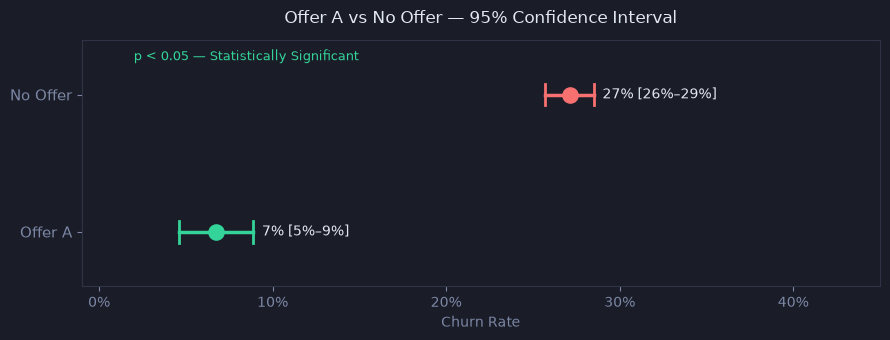

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.5))
fig.patch.set_facecolor('#1a1d27')
ax.set_facecolor('#1a1d27')

groups = ['No Offer', 'Offer A']

rates = [
    none_offer[0] / (none_offer[1] + none_offer[0]),
    A_offer[0] / (A_offer[1] + A_offer[0])
]

ci_lower = [
    ci_none_offer[0],
    ci_offer_a[0]
]

ci_upper = [
    ci_none_offer[1],
    ci_offer_a[1]
]

colors = ['#f87171', '#34d399']
y_pos = [1, 0]

for i, (g, r, lo, hi, c, y) in enumerate(zip(groups, rates, ci_lower, ci_upper, colors, y_pos)):

    ax.plot([lo, hi], [y, y], color=c, linewidth=2.5, zorder=2)
    ax.scatter(r, y, color=c, s=120, zorder=3)
    
    ax.plot([lo, lo], [y-0.08, y+0.08], color=c, linewidth=2)
    ax.plot([hi, hi], [y-0.08, y+0.08], color=c, linewidth=2)
    ax.text(hi + 0.005, y, f'{r:.0%} [{lo:.0%}–{hi:.0%}]',
            va='center', color='#e2e8f0', fontsize=10)


ax.set_yticks(y_pos)
ax.set_yticklabels(groups, color='#e2e8f0', fontsize=11)
ax.set_xlabel('Churn Rate', color='#7c87a6', fontsize=10)
ax.set_title('Offer A vs No Offer — 95% Confidence Interval',
             color='#e2e8f0', fontsize=12, pad=12)

ax.set_xlim(-0.01, 0.45)
ax.set_ylim(-0.4, 1.4)
ax.tick_params(colors='#7c87a6')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for spine in ax.spines.values():
    spine.set_edgecolor('#2e3347')

ax.text(0.02, 1.25, 'p < 0.05 — Statistically Significant',
        color='#34d399', fontsize=9, transform=ax.transData)

plt.tight_layout()
plt.savefig('forest_plot.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1d27')